Dataset Overview:
   customer_id signup_date first_purchase_date last_purchase_date  \
0         1001  2024-01-01          2024-01-01         2024-01-03   
1         1002  2024-01-01          2024-01-02         2024-06-15   
2         1003  2024-01-01          2024-01-05         2024-01-05   
3         1004  2024-01-02          2024-01-02         2024-03-10   
4         1005  2024-01-02          2024-01-04         2024-01-04   

   total_orders  days_active  churn  
0             2            3      1  
1            25          166      0  
2             1            1      1  
3             8           68      0  
4             1            1      1  

Total customers: 30
Churn rate: 50.0%

Churn by Signup Week:
                       churned  total  churn_rate
signup_week                                      
2024-01-01/2024-01-07        8     16         0.5
2024-01-08/2024-01-14        7     14         0.5


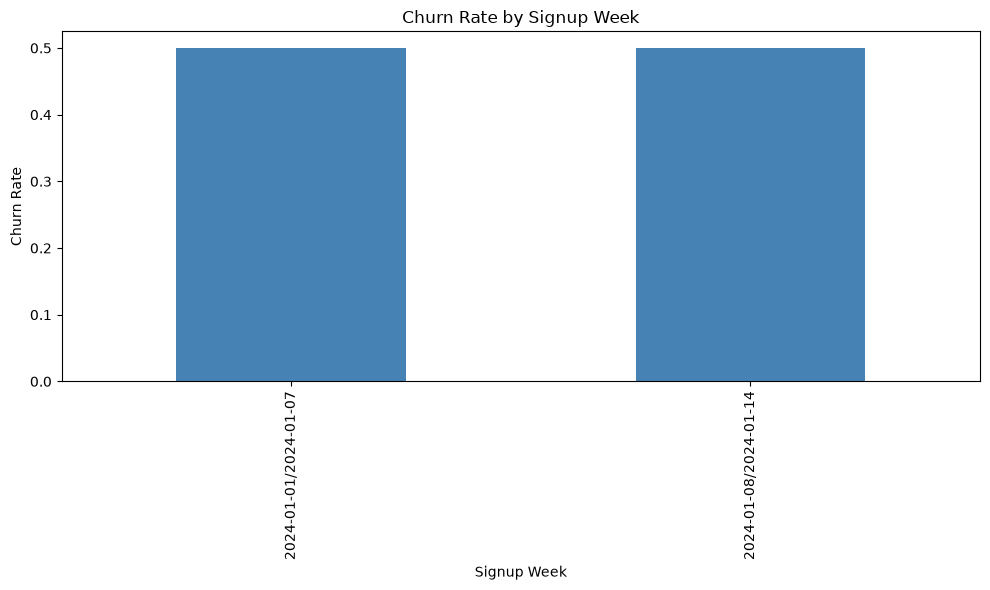


Churn by Purchase Timing:
                 churned  total  churn_rate
purchase_timing                            
Same Day               2     14    0.142857
Day 1-2                5      7    0.714286
Day 3                  7      8    0.875000
Day 4-7                1      1    1.000000


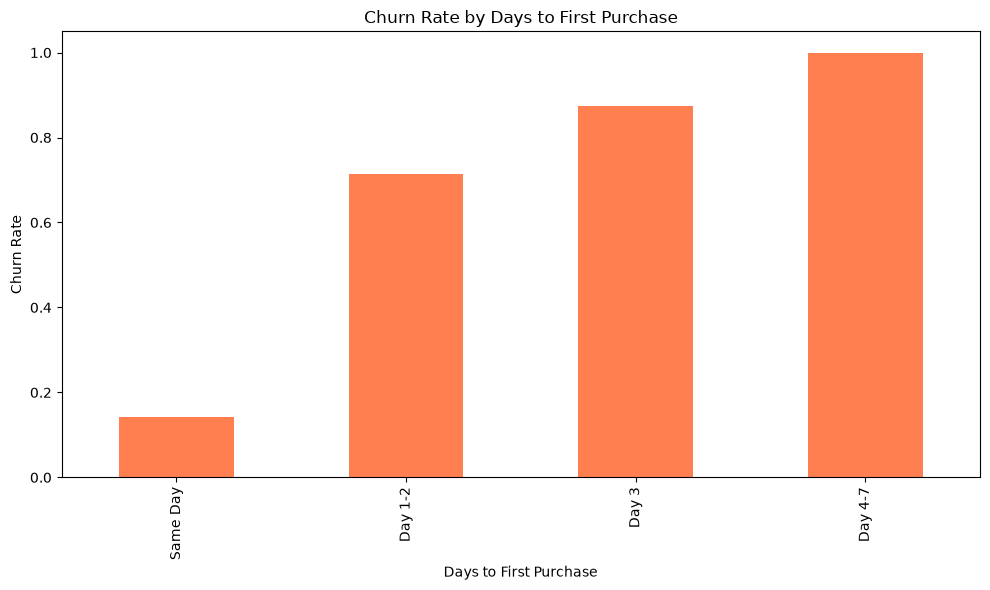


KEY FINDINGS SUMMARY
Overall churn rate: 50.0%
Customers who purchased same day: 14
Churn rate for same-day purchasers: 14.3%
Churn rate for users who never purchased fast: nan%


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('data/sample_data.csv')

# Display first few rows
print("Dataset Overview:")
print(df.head())
print(f"\nTotal customers: {len(df)}")
print(f"Churn rate: {df['churn'].mean():.1%}")

# Convert dates to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])

# Calculate days to first purchase
df['days_to_purchase'] = (df['first_purchase_date'] - df['signup_date']).dt.days

# Cohort Analysis: Group by signup week
df['signup_week'] = df['signup_date'].dt.to_period('W')

cohort_churn = df.groupby('signup_week')['churn'].agg(['sum', 'count', 'mean'])
cohort_churn.columns = ['churned', 'total', 'churn_rate']
print("\nChurn by Signup Week:")
print(cohort_churn)

# Visualization 1: Churn Rate by Week
plt.figure(figsize=(10, 6))
cohort_churn['churn_rate'].plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Signup Week')
plt.ylabel('Churn Rate')
plt.xlabel('Signup Week')
plt.tight_layout()
plt.savefig('churn_by_week.png')
plt.show()

# Behavioral Analysis: Days to first purchase
df['purchase_timing'] = pd.cut(df['days_to_purchase'], 
                                bins=[-1, 0, 1, 3, 7, 1000],
                                labels=['Same Day', 'Day 1-2', 'Day 3', 'Day 4-7', '8+ Days'])

purchase_churn = df.groupby('purchase_timing')['churn'].agg(['sum', 'count', 'mean'])
purchase_churn.columns = ['churned', 'total', 'churn_rate']
print("\nChurn by Purchase Timing:")
print(purchase_churn)

# Visualization 2: Churn by Purchase Timing
plt.figure(figsize=(10, 6))
purchase_churn['churn_rate'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Days to First Purchase')
plt.ylabel('Churn Rate')
plt.xlabel('Days to First Purchase')
plt.tight_layout()
plt.savefig('churn_by_purchase_timing.png')
plt.show()

# Key Metrics
print("\n" + "="*50)
print("KEY FINDINGS SUMMARY")
print("="*50)
print(f"Overall churn rate: {df['churn'].mean():.1%}")
print(f"Customers who purchased same day: {(df['days_to_purchase'] == 0).sum()}")
print(f"Churn rate for same-day purchasers: {df[df['days_to_purchase'] == 0]['churn'].mean():.1%}")
print(f"Churn rate for users who never purchased fast: {df[df['days_to_purchase'] > 7]['churn'].mean():.1%}")